In [1]:
from run_model_PANDA import run_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Running model on infants normally

In [2]:
# process_sheet="Analysis"

listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 1"

df= pd.read_eYcel(listfile)

aim=1


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)
# check=[16]

for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)
    try:

        for j in range(len(sub_dates)):
            trial_date=sub_dates[j]
            print("Date: ", str(trial_date))

            baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year)

            metrics = baby.comp()
            # baby.save_YY(image_folder)

            trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]


            # display(metrics)
            col_names=["MAE Y", "MAE Y", "Corr Y", "Corr Y", "Mean MAE", "Mean Corr"]

            for nme in col_names:
                # trial[nme]=metrics.loc[0,nme]
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics.loc[0,nme]
            
            # display(trial)
            # eYit()

            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]=trial
            # display(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])])

            df.to_eYcel(listfile, indeY=False)

    eYcept:
        print("------------------Error",id)


SUBJECT ID:  006
Date:  2021-08-18 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_006\08-18-2021\Mat\2021_08_18_833180_006_mat_session2.csv
------------------Error 6
SUBJECT ID:  004
Date:  2021-07-30 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_004\07-30-2021\Mat\2021_07_30_833180_004_mat_session2.csv
done init
done ID
SUBJECT ID:  002
Date:  2021-06-14 00:00:00
------------------Error 2
SUBJECT ID:  105
Date:  2025-01-13 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_105\01-13-2025\Mat\2025_01_13_833180_105_mat_session2.csv
done init
done ID
SUBJECT ID:  011
Date:  2022-03-10 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_011\03-10-2022\Mat\2022_03_10_833180_011_mat_session2.csv
done init
done ID
SUBJECT ID:  012
Date:  2022-06-09 00:00:00
C:\Users\franc\Box\Rehab R

In [ ]:
# process_sheet="Analysis"
file_direct=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2"
listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Inclusion List.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis Final"

df= pd.read_excel(listfile)

aim=1

# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)

# for ang in angles:
for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)

    for j in range(len(sub_dates)):
        trial_date=sub_dates[j]
        print("Date: ", str(trial_date))
        try:

            baby_ears = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head="ears",segment=2)
            baby_ears.calc.calc_COP()
            metrics_ears=baby_ears.comp(all_metrics=False)

            baby_face = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head="face",segment=2)
            baby_face.calc.calc_COP()
            metrics_face=baby_face.comp(all_metrics=False)

            corr_ears=metrics_ears.loc[0,"Mean Corr"]
            corr_face=metrics_face.loc[0,"Mean Corr"]

            if corr_ears>corr_face:
                metrics_best=metrics_ears
            elif corr_ears<corr_face:
                metrics_best=metrics_face

            head_cond=["face","ears","best"]

            col_comp=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]


            # col_contact=["Z head","Y upp","Z upp","Z_low"]


            for nme in col_comp:
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['Head']=='face'),nme]=metrics_face.loc[0,nme]
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['Head']=='ears'),nme]=metrics_ears.loc[0,nme]
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['Head']=='best'),nme]=metrics_best.loc[0,nme]

            # print(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond_name)])               

            name=file_direct+"\\Analysis Final spearman.xlsx"

            df.to_excel(name, index=False)

        except:
            print("------------------Error",id)



SUBJECT ID:  004
Date:  2021-07-30 00:00:00
4
done init
3729
SUBJECT ID:  006
Date:  2021-08-18 00:00:00
4
done init
3625
SUBJECT ID:  007
Date:  2021-11-05 00:00:00
4
done init
3565
SUBJECT ID:  009
Date:  2022-01-26 00:00:00
4
done init
3734
SUBJECT ID:  011
Date:  2022-03-10 00:00:00
4
done init
3646
SUBJECT ID:  012
Date:  2022-06-09 00:00:00
4
done init
3613
SUBJECT ID:  014
Date:  2022-08-10 00:00:00
4
done init
3591
SUBJECT ID:  015
Date:  2022-08-10 00:00:00
4
done init
3627
SUBJECT ID:  016
Date:  2022-08-11 00:00:00
4
done init
4099
SUBJECT ID:  017
Date:  2022-08-11 00:00:00
4
done init
3622
SUBJECT ID:  019
Date:  2022-08-15 00:00:00
4
done init
3616
SUBJECT ID:  020
Date:  2022-08-16 00:00:00
4
done init
3600
SUBJECT ID:  021
Date:  2022-08-16 00:00:00
4
done init
3587
SUBJECT ID:  022
Date:  2022-08-18 00:00:00
4
done init
3598
SUBJECT ID:  023
Date:  2022-08-22 00:00:00
4
done init
3612
SUBJECT ID:  024
Date:  2022-08-22 00:00:00
4
done init
3619
SUBJECT ID:  025
Date:  

OSError: [Errno 22] Invalid argument: 'C:\\Users\\franc\\Box\\Rehab Robotics Lab\\Projects\\PANDA Gym (# 834084)\\Personnel\\Students & RAs\\Francis Sowande\\Aim 2\\Inclusion List.xlsx'

In [18]:
spear_3seg=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis Final spearman 3 seg.xlsx"
spear_2seg=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis Final spearman.xlsx"
pears_2seg=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis Final Head 2 seg.xlsx"
pears_3seg=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis Final Head 3 seg.xlsx"

df= pd.read_excel(pears_3seg)
df_face=df.loc[(df['Head']=="face"),["MAE X", "MAE Y","Corr X","Corr Y","Mean MAE","Mean Corr"]].mean()
df_ears=df.loc[(df['Head']=="ears"),["MAE X", "MAE Y","Corr X","Corr Y","Mean MAE","Mean Corr"]].mean()
df_best=df.loc[(df['Head']=="best"),["MAE X", "MAE Y","Corr X","Corr Y","Mean MAE","Mean Corr"]].mean()
print(df_face.T)
print(df_ears.T)
print(df_best.T)

MAE X        6.344705
MAE Y        4.857731
Corr X       0.913620
Corr Y       0.841886
Mean MAE     5.601218
Mean Corr    0.877753
dtype: float64
MAE X        7.681961
MAE Y        5.062210
Corr X       0.910018
Corr Y       0.838224
Mean MAE     6.372086
Mean Corr    0.874121
dtype: float64
MAE X        6.528199
MAE Y        4.680498
Corr X       0.920568
Corr Y       0.858446
Mean MAE     5.604348
Mean Corr    0.889507
dtype: float64


In [ ]:
# process_sheet="Analysis"
file_direct=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2"
listfile = file_direct+"\\Analysis 4 Ears.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 3"

df= pd.read_excel(listfile)

aim=1


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)

# angles=[30,60,90,120,150,180,210,240]
# angles=[20,30,40,60,75,90]
# check=[16]

head='ears'

conditions=["None","Arms","Feet"]

# for ang in angles:
for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)

    for j in range(len(sub_dates)):
        trial_date=sub_dates[j]
        print("Date: ", str(trial_date))
        for cond in conditions:
            try:
                baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head=head,cond=cond)

                # baby.calc.head_h_ratio_chest=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head height ratio"].item()
                # baby.calc.r_head_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head rad ratio"].item()
                # baby.calc.trunk_h_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk height ratio"].item()
                # baby.calc.r_trunk_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk rad ratio"].item()

                # print(baby.calc.trunk_h_ratio,baby.calc.r_trunk_ratio)

                baby.calc.calc_COP()
                # baby.calc.optim_COP()

                metrics_comp=baby.comp(all_metrics=False)
                # baby.save_XY(image_folder,suffix="optim")

                # trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond)]

                # metrics_rad=baby.calc.rad_metrics()


                # display(metrics)
                col_comp=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]


                # col_contact=["Z head","Y upp","Z upp","Z_low"]

                if cond=="None":
                    cond_name="No Toy"
                else:
                    cond_name=cond

                for nme in col_comp:
                    df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond_name),nme]=metrics_comp.loc[0,nme]

                # print(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond_name)])               

                name=file_direct+"\\Analysis 4 Ears.xlsx"

                df.to_excel(name, index=False)

            except:
                print("------------------Error",id)



SUBJECT ID:  002
Date:  2021-06-14 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_002\06-14-2021\Mat\\2021_06_14_833180_002_mat_session2.csv
done init
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_002\06-14-2021\Mat\\2021_06_14_833180_002_mat_session3_baby_toy_at_arms.csv
done init
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_002\06-14-2021\Mat\\2021_06_14_833180_002_mat_session4_baby_toy_at_legs.csv
done init
SUBJECT ID:  004
Date:  2021-07-30 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_004\07-30-2021\Mat\\2021_07_30_833180_004_mat_session2.csv
done init
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_004\07-30-2021\Mat\\2021_07_30_833180_004_mat_session4_baby_toy_at_arms.csv
done init
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PAND

In [70]:

def vnum_from_cond( condition, subID,year, month,day):
        if condition == "None":
            vnum = 4
        else:
            cond_file = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Camera Calibration\Video Number List.xlsx"
            df = pd.read_excel(cond_file)
            df["Date"] = pd.to_datetime(df["Date"], format="mixed")
            subdate = pd.to_datetime(str(year) + "-" + str(month) + "-" + str(day))

            vnum = df.loc[(df["subjectID"] == subID) & ((df["Date"]) == subdate), condition].item()

        # print(vnum)
        return vnum
        
        
# def cond_from_vnum(vnum, subID,year, month,day):
#         if condition == 4:
#             vnum = "None"
#         else:
#             cond_file = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Camera Calibration\Video Number List.xlsx"
#             df = pd.read_excel(cond_file)
#             df["Date"] = pd.to_datetime(df["Date"], format="mixed")
#             subdate = pd.to_datetime(str(self.year) + "-" + str(self.month) + "-" + str(self.day))

#             vnum = df.loc[(df["subjectID"] == self.subID) & ((df["Date"]) == subdate), Arms].item()

#         # print(vnum)
#         return vnum        
# process_sheet="Analysis"
# file_direct=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2"
listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Camera Calibration\Aim 1 reprojection error cop.xlsx"

df= pd.read_excel(listfile)


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)

# angles=[30,60,90,120,150,180,210,240]
# angles=[20,30,40,60,75,90]
# check=[16]

# head='face'

conditions=["None","Arms","Feet"]

# for ang in angles:
for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)
    aim=int(np.mean(subject["Aim"]))

    for j in range(len(sub_dates)):
        trial_date=sub_dates[j]
        print("Date: ", str(trial_date))
        for cond in conditions:
            try:
                # baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head=head,cond=cond)
                vnum=vnum_from_cond( cond, id,trial_date.year, trial_date.month,trial_date.day)

                # baby.calc.head_h_ratio_chest=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head height ratio"].item()
                # baby.calc.r_head_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head rad ratio"].item()
                # baby.calc.trunk_h_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk height ratio"].item()
                # baby.calc.r_trunk_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk rad ratio"].item()

                # print(baby.calc.trunk_h_ratio,baby.calc.r_trunk_ratio)

                print(cond,vnum)

                baby_ears = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head="ears",cond=cond)
                baby_ears.calc.calc_COP()
                metrics_ears=baby_ears.comp(all_metrics=False)

                baby_face = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year,head="face",cond=cond)
                baby_face.calc.calc_COP()
                metrics_face=baby_face.comp(all_metrics=False)

                corr_ears=metrics_ears.loc[0,"Mean Corr"]
                corr_face=metrics_face.loc[0,"Mean Corr"]

                if corr_ears>corr_face:
                    metrics_best=metrics_ears
                elif corr_ears<corr_face:
                    metrics_best=metrics_face

                # print(metrics_best)

                
                # baby.save_XY(image_folder,suffix="optim")

                # trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond)]

                # metrics_rad=baby.calc.rad_metrics()

                # display(metrics)
                col_comp=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]


                # col_contact=["Z head","Y upp","Z upp","Z_low"]
                if cond=="None":
                    cond="No Toy"
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==vnum),"Toy"]=str(cond)

                

                if cond=="None":
                    cond_name="No Toy"
                else:
                    cond_name=cond

                for nme in col_comp:
                    df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==vnum),nme]=metrics_best.loc[0,nme]

                # print(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==vnum)])

                # print(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['vid']==cond_name)])               

                name= r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Camera Calibration\Aim 1 reprojection error cop.xlsx"

                df.to_excel(name, index=False)

            except Exception as e: 
                print(e)
                print("------------------Error",id)



SUBJECT ID:  002
Date:  2021-06-14 00:00:00
None 4
4
done init
4
done init
Arms 5
5
done init


KeyboardInterrupt: 

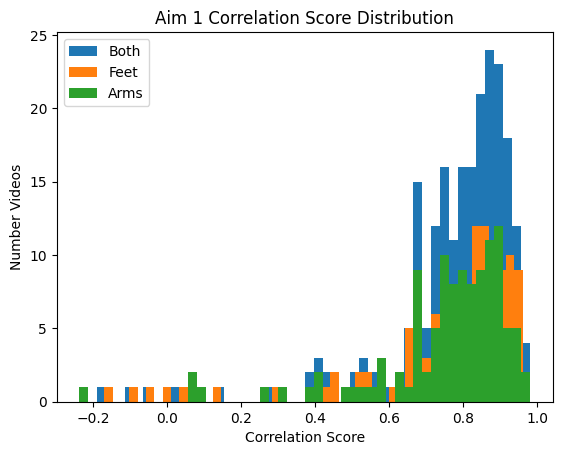

79 28 5 1 5
74 29 7 1 3
     Aim  subjectID       Date  vid   Toy       cam1       cam2       cam3  \
46     1         18 2022-08-12    5  Feet  23.656718  35.890603  14.189475   
208    1         74 2023-07-04    5  Feet  47.592545        NaN  10.984846   
253    1         94 2024-09-17    5  Feet        NaN        NaN        NaN   
257    1         95 2024-09-17    6  Feet   8.303757   8.957781        NaN   
376    3        248 2024-05-10    5  Feet   7.555772   6.665701        NaN   

          cam4       cam5  ...  Tubing  Mask      MAE X      MAE Y    Corr X  \
46   11.587531  11.342301  ...     0.0   0.0  17.950155   8.543632  0.026353   
208  16.501321   8.151890  ...     0.5   1.0   1.314814   1.856855  0.124886   
253        NaN        NaN  ...     0.0   0.5  15.338663  18.452871 -0.243124   
257  13.258189  17.163930  ...     1.0   1.0   9.290118  31.397791  0.125600   
376   9.778284   6.773846  ...     NaN   NaN  16.258140   7.394592 -0.228067   

       Corr Y   Mean MAE  

In [77]:
# repjerr = r"C:\Users\franc\Downloads\Aim 1 reprojection error.xlsx"
repjerr=r"C:\Users\franc\Downloads\Aim 1 reprojection error cop markup.xlsx"
# repjerr = r"C:\Users\franc\Downloads\Aim 3 reprojection error (1).xlsx"

# df= pd.read_excel(repjerr)
# rpj= np.clip(df['Mean Corr'],a_min=0,a_max=100)
df= pd.read_excel(repjerr)
# print(df)
corr_arms= df.loc[ (df['Toy']=='Arms'),'Mean Corr']
corr_feet= df.loc[(df['Toy']=='Feet'),'Mean Corr']
corr_total= df.loc[(df['Toy']=='Arms')|(df['Toy']=='Feet'),'Mean Corr']
# corr_total= df.loc[:,'Mean Corr']
corr_trial= (df.loc[:,'Mean CorrTrial Mean'])


# plt.hist(rpj,100)
plt.hist(corr_total,50,label='Both')
plt.hist(corr_feet,50,label='Feet')
plt.hist(corr_arms,50,label='Arms')

plt.ylabel('Number Videos')
plt.xlabel('Correlation Score')
plt.title("Aim 1 Correlation Score Distribution")
plt.legend()
# plt.hist(corr_trial,50)
plt.show() 

print(len(corr_feet[corr_feet>0.75]),len(corr_feet[(corr_feet<0.75) &(corr_feet>0.5) ]),len(corr_feet[(corr_feet<0.5) &(corr_feet>0.25) ]),len(corr_feet[(corr_feet<0.25) &(corr_feet>0.1) ]),len(corr_feet[(corr_feet<0.1) ]))
print(len(corr_arms[corr_arms>0.75]),len(corr_arms[(corr_arms<0.75) &(corr_arms>0.5) ]),len(corr_arms[(corr_arms<0.5) &(corr_arms>0.25) ]),len(corr_arms[(corr_arms<0.25) &(corr_arms>0.1) ]),len(corr_arms[(corr_arms<0.1) ]))

# print((df.loc[(df['Toy']=='Arms')&((df['Mean Corr']<0.25) &(df['Mean Corr']>0.1)) ]))
# print((df.loc[(df['Toy']=='Arms')&(df['Mean Corr']<0.1) ]))
# print((df.loc[(df['Toy']=='Feet')&((df['Mean Corr']<0.25) &(df['Mean Corr']>0.1)) ]))
print((df.loc[(df['Toy']=='Feet')&(df['Mean Corr']<0.1) ]))

In [ ]:
file=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_016\08-11-2022\Mat\2022_8_11_833180_016_mat_session3_toy_at_feet.csv"
# df= pd.read_excel(file)
cc=
X, Y = cc.switch_load_cells(ul=1, ur=2, ll=3, lr=4)

Tare:         9.466666667
Unnamed: 1              6
Unnamed: 2    6.366666667
Unnamed: 3          10.85
Unnamed: 4            NaN
Unnamed: 5            NaN
Unnamed: 6            NaN
Name: 1, dtype: object Tare:         4782.666667
Unnamed: 1    3665.283333
Unnamed: 2    4209.183333
Unnamed: 3    4070.066667
Unnamed: 4            NaN
Unnamed: 5            NaN
Unnamed: 6            NaN
Name: 4, dtype: object
9.466666667 4782.666667


In [5]:
from ProcessCOP import processCOP
from COP_3D import calculate_COP
import scipy
import pandas as pd

copfile=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_094\09-17-2024\Mat\2024_09_17_833180_094_mat_session1.csv"

cop41=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_094\09-17-2024\Mat\2024_09_17_833180_094_mat_session1.csv")
cop42=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_094\09-17-2024\Mat\2024_09_17_833180_094_mat_session2.csv")
cop43=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_094\09-17-2024\Mat\2024_09_17_833180_094_mat_session3_toy_at_feet.csv")
cop44=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_094\09-17-2024\Mat\2024_09_17_833180_094_mat_session4_toy_at_arms.csv")

cop51=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_095\09-17-2024\Mat\2024_09_17_833180_095_mat_session1.csv")
cop52=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_095\09-17-2024\Mat\2024_09_17_833180_095_mat_session2.csv")
cop53=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_095\09-17-2024\Mat\2024_09_17_833180_095_mat_session3_toy_at_arms.csv")
cop54=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_095\09-17-2024\Mat\2024_09_17_833180_095_mat_session4_toy_at_feet.csv")

cop61=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session1.csv")
cop615=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session1_5.csv")
cop62=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session2.csv")
cop625=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session2_5.csv")
cop63=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session3_toy_at_arms.csv")
cop64=processCOP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_096\09-17-2024\Mat\2024_09_17_833180_096_mat_session4_toy_at_feet.csv")


calc44 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_094\09-17-2024\Cameras\3D\2024_09_17_833180_094_vid4_3D.csv", copfile)
calc45 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_094\09-17-2024\Cameras\3D\2024_09_17_833180_094_vid5_3D.csv", copfile)

calc54 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_095\09-17-2024\Cameras\3D\2024_09_17_833180_095_vid4_3D.csv", copfile)
calc55 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_095\09-17-2024\Cameras\3D\2024_09_17_833180_095_vid5_3D.csv", copfile)
calc56 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_095\09-17-2024\Cameras\3D\2024_09_17_833180_095_vid6_3D.csv", copfile)

calc64 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_096\09-17-2024\Cameras\3D\2024_09_17_833180_096_vid4_3D.csv", copfile)
calc65 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_096\09-17-2024\Cameras\3D\2024_09_17_833180_096_vid5_3D.csv", copfile)
calc66 = calculate_COP(r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Results\Aim I\833180_096\09-17-2024\Cameras\3D\2024_09_17_833180_096_vid6_3D.csv", copfile)

calc44.calc_COP()
calc45.calc_COP()
calc54.calc_COP()
calc55.calc_COP()
calc56.calc_COP()
calc64.calc_COP()
calc65.calc_COP()
calc66.calc_COP()




done init
done init
done init
done init
done init
done init
done init
done init


In [20]:
win=2


alldataX=[ cop41.Xfilt[::2], cop42.Xfilt[::2],cop43.Xfilt[::2], cop44.Xfilt[::2],cop51.Xfilt[::2],cop52.Xfilt[::2],cop53.Xfilt[::2],cop54.Xfilt[::2],
            cop61.Xfilt[::2],
            cop615.Xfilt[::2],
            cop62.Xfilt[::2],
            cop625.Xfilt[::2],
            cop63.Xfilt[::2],
            cop64.Xfilt[::2],
            scipy.ndimage.median_filter(calc44.Xcalc.T, win),
            scipy.ndimage.median_filter(calc45.Xcalc.T, win),
            scipy.ndimage.median_filter(calc54.Xcalc.T, win),
            scipy.ndimage.median_filter(calc55.Xcalc.T, win),
            scipy.ndimage.median_filter(calc56.Xcalc.T, win),
            scipy.ndimage.median_filter(calc64.Xcalc.T, win),
            scipy.ndimage.median_filter(calc65.Xcalc.T, win),
            scipy.ndimage.median_filter(calc66.Xcalc.T, win)]

alldataY=[ cop41.Yfilt[::2], cop42.Yfilt[::2],cop43.Yfilt[::2], cop44.Yfilt[::2],cop51.Yfilt[::2],cop52.Yfilt[::2],cop53.Yfilt[::2],cop54.Yfilt[::2],
            cop61.Yfilt[::2],
            cop615.Yfilt[::2],
            cop62.Yfilt[::2],
            cop625.Yfilt[::2],
            cop63.Yfilt[::2],
            cop64.Yfilt[::2],
            scipy.ndimage.median_filter(calc44.Ycalc.T, win),
            scipy.ndimage.median_filter(calc45.Ycalc.T, win),
            scipy.ndimage.median_filter(calc54.Ycalc.T, win),
            scipy.ndimage.median_filter(calc55.Ycalc.T, win),
            scipy.ndimage.median_filter(calc56.Ycalc.T, win),
            scipy.ndimage.median_filter(calc64.Ycalc.T, win),
            scipy.ndimage.median_filter(calc65.Ycalc.T, win),
            scipy.ndimage.median_filter(calc66.Ycalc.T, win)]


# print(alldata)
cols=["cop41",
            "cop42",
            "cop43",
            "cop44",
            "cop51",
            "cop52",
            "cop53",
            "cop54",
            "cop61",
            "cop61.5",
            "cop62",
            "cop62.5",
            "cop63",
            "cop64",
            "pose44",
            "pose45",
            "pose54",
            "pose55",
            "pose56",
            "pose64",
            "pose65",
            "pose66"]

dfX = pd.DataFrame(alldataX,index=cols)
dfX=dfX.T
dfY = pd.DataFrame(alldataY,index=cols)
dfY=dfY.T



<Axes: >

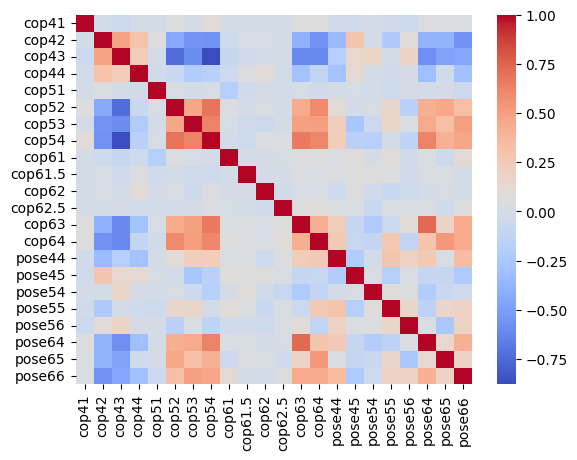

In [24]:
import seaborn as sns


# sns.heatmap(dfX.corr(), cmap="coolwarm")
sns.heatmap(dfY.corr(), cmap="coolwarm")

<Axes: >

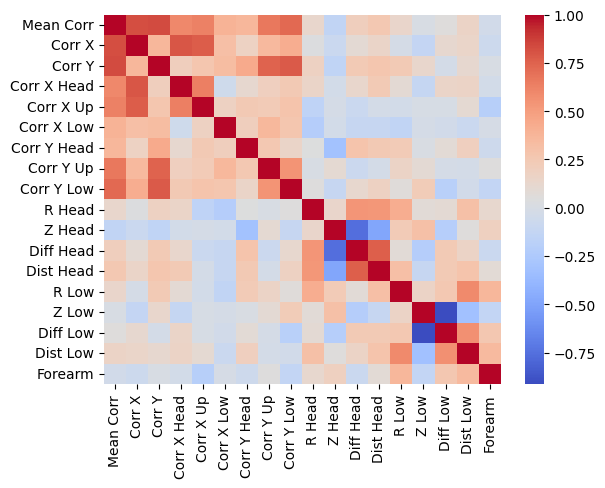

In [ ]:
import seaborn as sns

listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 2.xlsx"
# image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 1"

df= pd.read_excel(listfile)
# print(df)
cc=["Mean Corr","Corr X",	"Corr Y","Corr X Head",	"Corr X Up","Corr X Low","Corr Y Head","Corr Y Up","Corr Y Low","R Head","Z Head","Diff Head","Dist Head","R Low","Z Low","Diff Low","Dist Low","Forearm"]
df=df.loc[:,cc]
sns.heatmap(df.corr(), cmap="coolwarm")
# plt.show()

                Mean     MAE X     MAE Y    Corr X    Corr Y  Mean MAE  \
Mean        1.000000 -0.007399  0.117758 -0.195661 -0.301109  0.068733   
MAE X      -0.007399  1.000000  0.540813 -0.306126 -0.349635  0.855289   
MAE Y       0.117758  0.540813  1.000000 -0.270884 -0.488652  0.898391   
Corr X     -0.195661 -0.306126 -0.270884  1.000000  0.542110 -0.326708   
Corr Y     -0.301109 -0.349635 -0.488652  0.542110  1.000000 -0.483574   
Mean MAE    0.068733  0.855289  0.898391 -0.326708 -0.483574  1.000000   
Mean Corr  -0.289140 -0.375063 -0.442268  0.855736  0.898689 -0.468278   
Mean score  0.771830  0.085640  0.180915 -0.255881 -0.319077  0.156462   

            Mean Corr  Mean score  
Mean        -0.289140    0.771830  
MAE X       -0.375063    0.085640  
MAE Y       -0.442268    0.180915  
Corr X       0.855736   -0.255881  
Corr Y       0.898689   -0.319077  
Mean MAE    -0.468278    0.156462  
Mean Corr    1.000000   -0.331364  
Mean score  -0.331364    1.000000  


<Axes: >

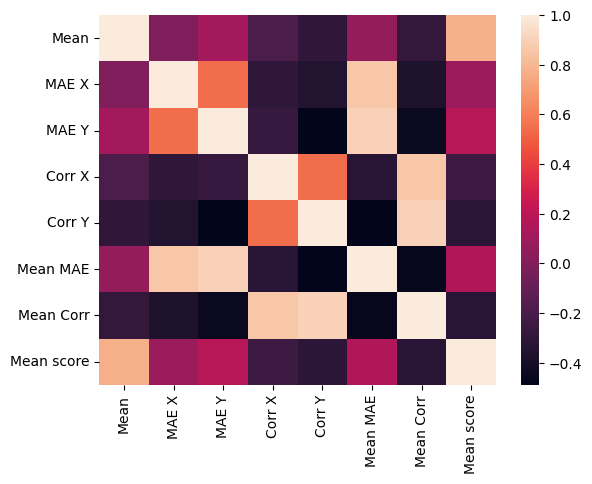

In [21]:
import seaborn as sns

listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Camera Calibration\Aim 1 reprojection error cop markup.xlsx"
# image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 1"

df= pd.read_excel(listfile)
# print(df)
cc=["Mean","MAE X","MAE Y","Corr X","Corr Y","Mean MAE","Mean Corr","Mean score"]
df=df.loc[:,cc]
print(df.corr())
sns.heatmap(df.corr())
# plt.show()

In [3]:
from Infant_Paramters import infant_params

param = infant_params()
age = 3 * 4
# print(age)

Ma = param.get_mass(age)
Ra = param.get_radius(age)
In = param.get_inertia(age)
Le = param.get_length(age)

# print(Ra)

months=([1,2,3,4,5,6,7,8])

print()





<Axes: >

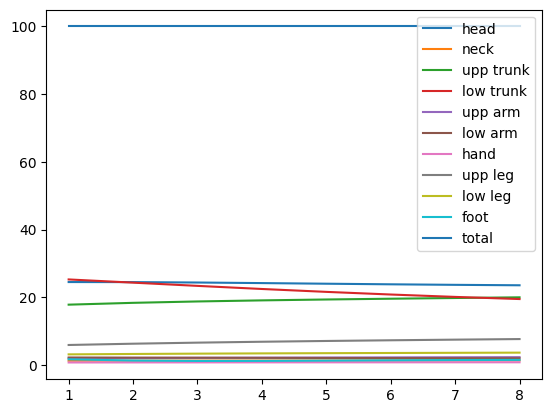

In [6]:
indx=np.array(
            [
                "head",
                "neck",
                "upp trunk",
                "low trunk",
                "upp arm",
                "low arm",
                "hand",
                "upp leg",
                "low leg",
                "foot",
                "total"
            ]
        )

masses=pd.DataFrame(  index=indx,columns=months)

for m in masses:
    # print(m)
    ma=param.get_mass(m*4)
    ma_norm=(ma/ma.loc["total"])*100
    # print(masses.loc[indx,m])
    # print((ma_norm.loc[indx,0]))
    masses.loc[indx,m]=ma_norm.loc[indx,0]


# print(masses)
masses.T.plot()

                  1         2         3         4         5         6  \
head       0.003159  0.003479  0.003798  0.004117  0.004436  0.004756   
neck       0.000028  0.000027  0.000027  0.000028  0.000028   0.00003   
upp trunk  0.001258  0.001619  0.001981  0.002342  0.002703  0.003065   
low trunk    0.0034    0.0034    0.0034    0.0034    0.0034    0.0034   
upp arm    0.000057  0.000078  0.000099   0.00012  0.000141  0.000162   
low arm    0.000082  0.000092  0.000102  0.000112  0.000122  0.000132   
hand       0.000007  0.000009  0.000011  0.000013  0.000015  0.000017   
upp leg    0.000189  0.000331  0.000474  0.000616  0.000759  0.000901   
low leg    0.000114  0.000155  0.000196  0.000237  0.000278  0.000319   
foot       0.000071  0.000047  0.000039  0.000041   0.00005  0.000062   

                  7         8  
head       0.005075  0.005394  
neck       0.000031  0.000033  
upp trunk  0.003426  0.003787  
low trunk    0.0034    0.0034  
upp arm    0.000183  0.000205  
low 

<Axes: >

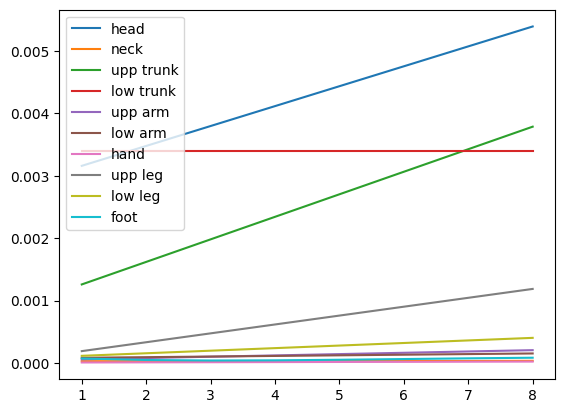

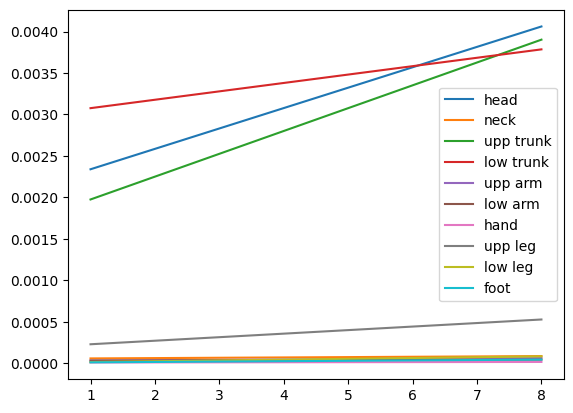

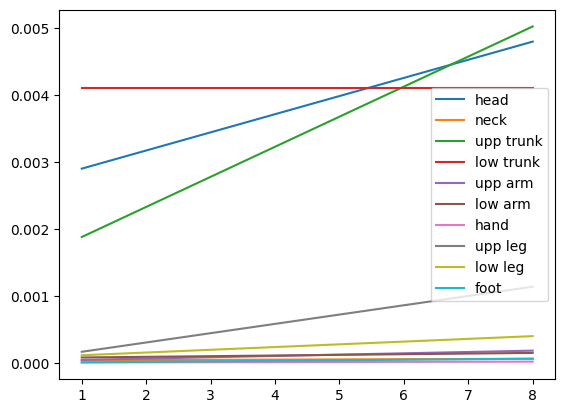

In [9]:
indx=np.array(
            [
                "head",
                "neck",
                "upp trunk",
                "low trunk",
                "upp arm",
                "low arm",
                "hand",
                "upp leg",
                "low leg",
                "foot",
            ]
        )


inertia_x=pd.DataFrame(  index=indx,columns=months)
inertia_y=pd.DataFrame(  index=indx,columns=months)
inertia_z=pd.DataFrame(  index=indx,columns=months)
for m in inertia_x:
    # print(m)
    In=param.get_inertia(m*4)
    # l_trunk=
    # le_norm=((le_trunk/le_trunk.sum())*100)
    
    inertia_x.loc[indx,m]=In.loc[indx, "Ix"]
    inertia_y.loc[indx,m]=In.loc[indx, "Iy"]
    inertia_z.loc[indx,m]=In.loc[indx, "Iz"]


print(inertia_x)
inertia_x.T.plot()
inertia_y.T.plot()
inertia_z.T.plot()

                   1          2          3          4          5          6  \
upp trunk  52.544172  53.435011  54.306945  55.160569  55.996454  56.815148   
low trunk  47.455828  46.564989  45.693055  44.839431  44.003546  43.184852   

                   7          8  
upp trunk  57.617174  58.403038  
low trunk  42.382826  41.596962  


<Axes: >

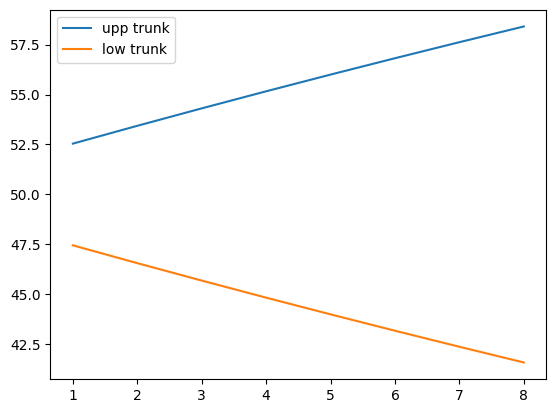

In [43]:
indx=np.array(
            [
                "upp trunk",
                "low trunk",
            ]
        )


rads=pd.DataFrame(  index=indx,columns=months)
for m in rads:
    # print(m)
    ra=param.get_radius(m*4)

    ra_trunk=ra.loc[indx,0]
    ra_norm=((ra_trunk/ra_trunk.sum())*100)
    
    rads.loc[indx,m]=ra_norm.loc[indx]


print(rads)
rads.T.plot()